# **Project Name** - House Prices Prediction using Machine Learning

##### **Project Type**    - Regression
##### **Contribution**    - Individual

# **Project Summary -**

This project builds a machine learning model to predict a house's sale price from its structural, locational, and quality-related features. The dataset contains 1,460 residential property records with 81 columns, covering property information (lot size, zoning, shape), location details (neighborhood, nearby conditions), building characteristics (overall quality/condition, year built), basement, garage, and living-area measurements, and sale information.

Data preparation began with a missing-value audit: columns with more than 50% missing data (Alley, PoolQC, Fence, MiscFeature, FireplaceQu, MasVnrType) were dropped, numeric columns (LotFrontage, MasVnrArea, GarageYrBlt) were median-imputed, and categorical columns (basement and garage quality/condition fields, Electrical) were mode-imputed. Categorical features were then one-hot encoded.

Exploratory analysis showed that Neighborhood, Overall Quality, Ground Living Area, and Garage Capacity all have a strong relationship with Sale Price, and that several numeric features (SalePrice, LotArea, GrLivArea) are right-skewed with genuine high-value outliers that were kept in the data rather than removed, since tree-based models handle them well.

Five regression models were built and compared: Linear Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost. The ensemble models clearly outperformed the linear baseline, confirming that the relationship between house features and price is largely non-linear. XGBoost was the best performer, achieving the highest R² Score (0.909) and the lowest MAE and RMSE among all models, and was selected as the final model, with hyperparameter tuning via GridSearchCV confirming the choice.

# **GitHub Link -**

_Add your GitHub repository link here._

# **Problem Statement**

The objective of this project is to develop a machine learning model that can accurately predict the selling price of a house based on its various characteristics, such as location, area, quality, number of rooms, garage capacity, and other structural features.

The project also aims to analyze the relationship between different house features and their impact on sale price, compare the performance of multiple regression models, and recommend the most suitable model for production. 
    
The insights obtained from this analysis can help customers make informed decisions while buying or selling houses. 
    
This matches the objectives specified in the project brief

# **General Guidelines** : -

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus.
3.   Each and every logic should have proper comments.
4.   Add as many charts as needed. For each chart, answer:

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
*   Will the gained insights help creating a positive business impact?

[ Hints: Do the visualization in a structured way following the **UBM** Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical-Categorical, Numerical-Numerical, Categorical-Categorical),

M - Multivariate Analysis ]

5.   For each ML algorithm, explain the model, its performance, cross-validation & hyperparameter tuning, and the business impact of the evaluation metrics used.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [14]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualizatiuon
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Preprocessing or Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# installations
!pip install xgboost

### Dataset Loading

In [16]:
df = pd.read_csv("data.csv")

### Dataset First View

In [20]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [22]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


### Dataset Rows & Columns count

In [25]:
df.shape

(1460, 81)

As we can see int this dataset, we have a total of 1460 rows and 81 columns. Each row represent a new house and for columns it tells about features

### Dataset Information

In [29]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [33]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


#### Duplicate Values

In [36]:
# Checking for duplicate rows in the dataset
df.duplicated().sum()

0

#### Missing Values/Null Values

In [39]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [41]:
df.isnull().sum()[df.isnull().sum()>0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

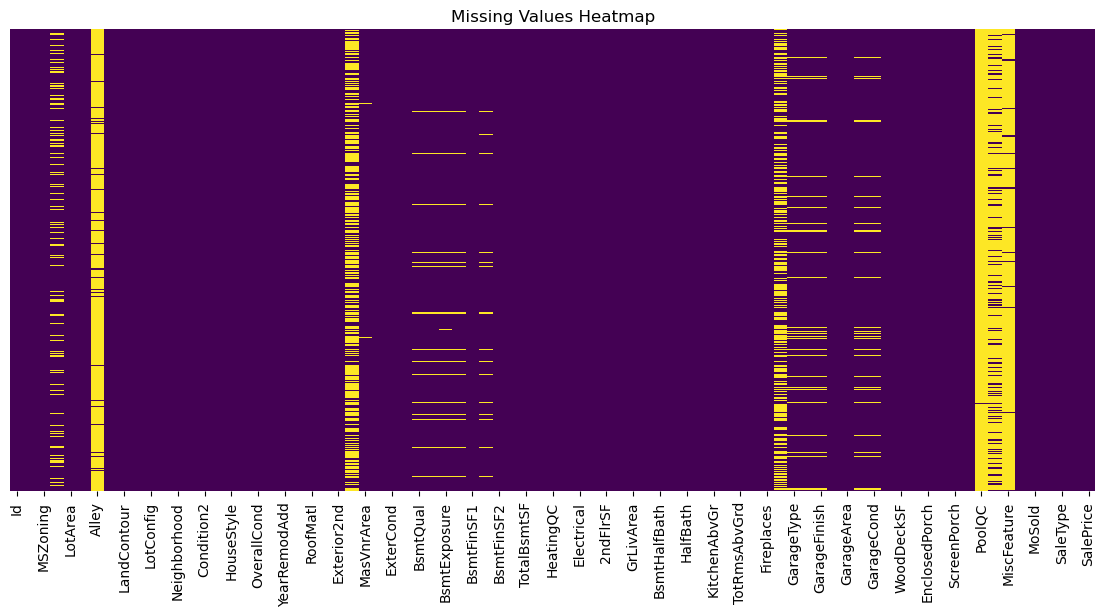

In [43]:
# Visualizing missing values
plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

The dataset has 1,460 rows and 81 columns, each row describing one residential property sale and its features (lot/location details, building and quality attributes, basement/garage/living-area measurements, and sale conditions), with **SalePrice** as the target. Several columns (Alley, PoolQC, Fence, MiscFeature, FireplaceQu, MasVnrType) have a very high percentage of missing values (>50%), while a handful of numeric columns (LotFrontage, MasVnrArea, GarageYrBlt) and categorical basement/garage columns have smaller amounts of missingness that need imputation before modeling.

## ***2. Understanding Your Variables***

In [48]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [50]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Variables Description

**Target Variable**
- `SalePrice` — Selling price of the house.

**Property Information** — MSSubClass, MSZoning, LotFrontage, LotArea, Street, Alley, LotShape, LandContour, Utilities, LotConfig, LandSlope

**Location Details** — Neighborhood, Condition1, Condition2

**Building Characteristics** — BldgType, HouseStyle, OverallQual, OverallCond, YearBuilt, YearRemodAdd

**Exterior Features** — RoofStyle, RoofMatl, Exterior1st, Exterior2nd, MasVnrType, MasVnrArea, ExterQual, ExterCond

**Basement Features** — Foundation, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinSF1, BsmtFinType2, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF

**Heating & Electrical** — Heating, HeatingQC, CentralAir, Electrical

**Living Area Features** — 1stFlrSF, 2ndFlrSF, LowQualFinSF, GrLivArea

**Bathrooms & Rooms** — BsmtFullBath, BsmtHalfBath, FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, KitchenQual, TotRmsAbvGrd, Functional

**Garage Features** — GarageType, GarageYrBlt, GarageFinish, GarageCars, GarageArea, GarageQual, GarageCond

**Outdoor Features** — WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, PoolQC, Fence, MiscFeature, MiscVal

**Sale Information** — MoSold, YrSold, SaleType, SaleCondition

### Check Unique Values for each variable.

In [55]:
# Checking number of unique values in each column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Id: 1460 unique values
MSSubClass: 15 unique values
MSZoning: 5 unique values
LotFrontage: 110 unique values
LotArea: 1073 unique values
Street: 2 unique values
Alley: 2 unique values
LotShape: 4 unique values
LandContour: 4 unique values
Utilities: 2 unique values
LotConfig: 5 unique values
LandSlope: 3 unique values
Neighborhood: 25 unique values
Condition1: 9 unique values
Condition2: 8 unique values
BldgType: 5 unique values
HouseStyle: 8 unique values
OverallQual: 10 unique values
OverallCond: 9 unique values
YearBuilt: 112 unique values
YearRemodAdd: 61 unique values
RoofStyle: 6 unique values
RoofMatl: 8 unique values
Exterior1st: 15 unique values
Exterior2nd: 16 unique values
MasVnrType: 3 unique values
MasVnrArea: 327 unique values
ExterQual: 4 unique values
ExterCond: 5 unique values
Foundation: 6 unique values
BsmtQual: 4 unique values
BsmtCond: 4 unique values
BsmtExposure: 4 unique values
BsmtFinType1: 6 unique values
BsmtFinSF1: 637 unique values
BsmtFinType2: 6 unique va

## 3. ***Data Wrangling***

### Data Wrangling Code

In [59]:
df.isnull().sum().sum()

7829

In [61]:
Droped_columns = ["Alley",
                  "MasVnrType",
                  "FireplaceQu",
                  "PoolQC",
                  "Fence",
                  "MiscFeature"
                 ]
df.drop(columns=Droped_columns, inplace=True)

Columns such as Alley, PoolQC, Fence, MiscFeature, FireplaceQu, and MasVnrType have a very high percentage of missing values (more than 50%). Since imputing such a large number of missing values could introduce bias, these columns were removed from the dataset.

In [64]:
df.isnull().sum().sum()

860

In [66]:
df.isnull().sum()[df.isnull().sum()>0]

LotFrontage     259
MasVnrArea        8
BsmtQual         37
BsmtCond         37
BsmtExposure     38
BsmtFinType1     37
BsmtFinType2     38
Electrical        1
GarageType       81
GarageYrBlt      81
GarageFinish     81
GarageQual       81
GarageCond       81
dtype: int64

In [68]:
Numbered_columns = ["LotFrontage","MasVnrArea","GarageYrBlt"]

for i in Numbered_columns:
    df[i].fillna(df[i].median(),inplace = True)

In [70]:
df.isnull().sum().sum()

512

In [72]:
df.isnull().sum()[df.isnull().sum()>0]

BsmtQual        37
BsmtCond        37
BsmtExposure    38
BsmtFinType1    37
BsmtFinType2    38
Electrical       1
GarageType      81
GarageFinish    81
GarageQual      81
GarageCond      81
dtype: int64

In [74]:
Categorical_columns =[ "BsmtQual",
                       "BsmtCond",
                       "BsmtExposure",
                       "BsmtFinType1",
                       "BsmtFinType2",
                       "Electrical",
                       "GarageType",
                       "GarageFinish",
                       "GarageQual",
                       "GarageCond"
                     ]
for i in Categorical_columns:
    df[i].fillna(df[i].mode()[0],inplace=True)

In [76]:
df.select_dtypes(include="object").columns

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
       'SaleType', 'SaleCondition'],
      dtype='object')

### What all manipulations have you done and insights you found?

Columns with more than 50% missing values (Alley, PoolQC, Fence, MiscFeature, FireplaceQu, MasVnrType) were dropped since imputing that much missing data would introduce bias. The remaining numeric columns with missing values (LotFrontage, MasVnrArea, GarageYrBlt) were imputed with their median, and the remaining categorical columns (basement and garage quality/condition fields, Electrical) were imputed with their mode. After this step, the dataset has zero missing values and is ready for encoding and modeling.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Univariate Analysis

#### Chart 1 – Sale Price Distribution

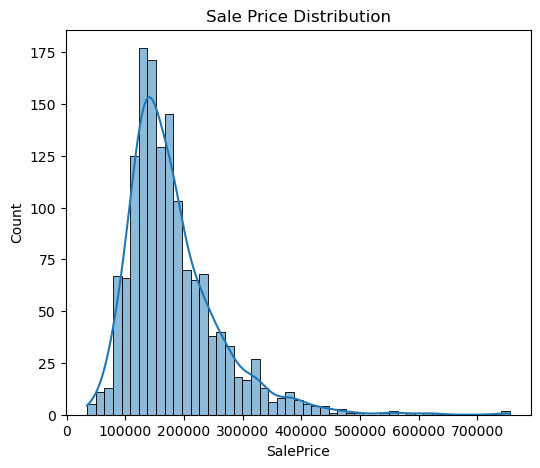

In [83]:
plt.figure(figsize=(6,5))
sns.histplot(df["SalePrice"], kde=True)
plt.title("Sale Price Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE overlay is the standard way to see the shape, spread, and skew of a single continuous target variable like SalePrice.

##### 2. What is/are the insight(s) found from the chart?

The distribution of SalePrice is right-skewed, indicating that most houses are sold in the lower-to-middle price range, while a smaller number of houses have very high sale prices.

##### 3. Will the gained insights help creating a positive business impact?

Yes — knowing the price distribution is right-skewed tells us most transactions happen in the lower-to-middle range, which is useful for setting realistic pricing expectations and flags that a log-transform or robust evaluation metric may help modeling.

#### Chart 2 – Distribution of Key Numeric Features

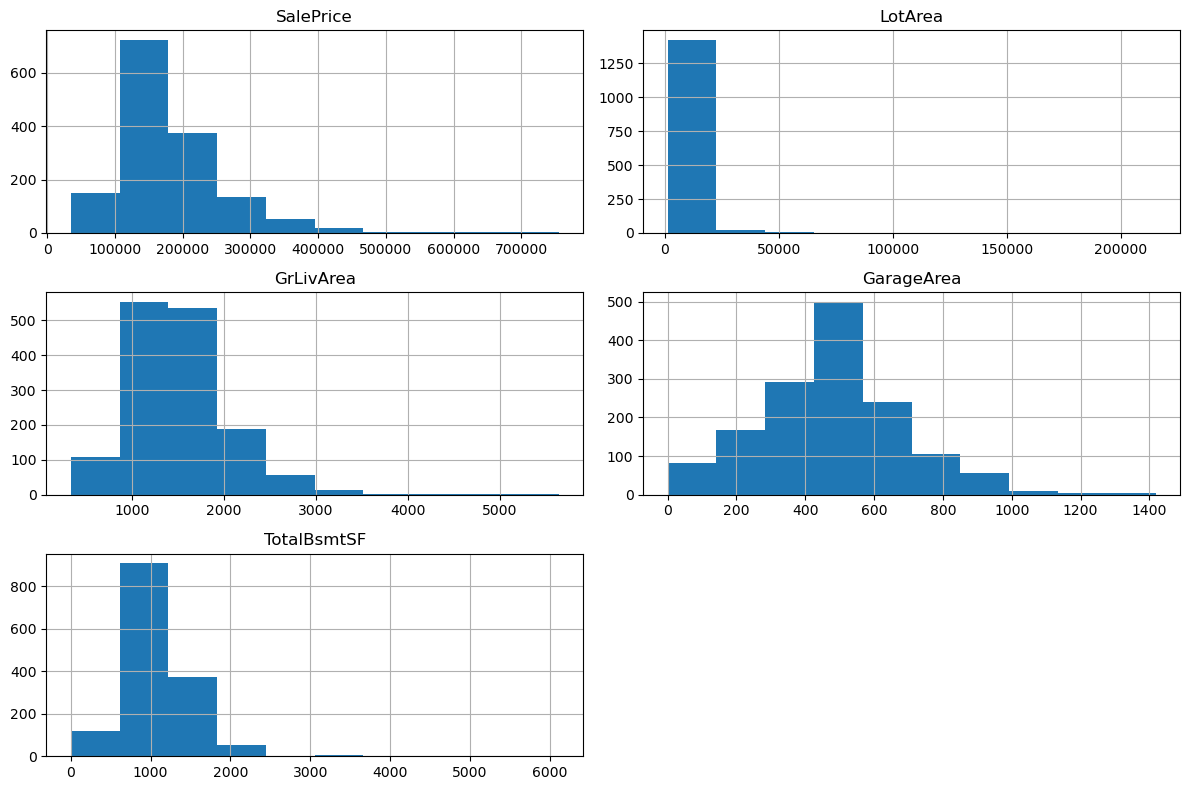

In [92]:
num_cols = [
    "SalePrice",
    "LotArea",
    "GrLivArea",
    "GarageArea",
    "TotalBsmtSF"
]

df[num_cols].hist(
    figsize=(12,8)
)

plt.tight_layout()

plt.show()

##### 1. Why did you pick the specific chart?

Histograms for SalePrice, LotArea, GrLivArea, GarageArea, and TotalBsmtSF together let us quickly compare the shape and skew of several important numeric variables at once.

##### 2. What is/are the insight(s) found from the chart?

This visualization helps us understand:
* SalePrice: Most houses are priced between approximately ₹100,000 and ₹250,000, with only a few premium houses costing much more.
* LotArea: Most properties have relatively small lot sizes, while a few have exceptionally large plots (outliers).
* GrLivArea: The majority of houses have living areas between 1,000 and 2,000 sq. ft., with only a few very large homes.
* GarageArea: Most garages are of average size, with fewer houses having very large garages.
* TotalBsmtSF: Most houses have basement areas around 800–1,200 sq. ft., while a small number have unusually large basements.
Conclusion

The histogram analysis reveals that several important numerical features are right-skewed and contain outliers. This indicates that a small number of properties have exceptionally large sizes or high prices compared to the majority. Understanding these distributions helps in selecting suitable preprocessing techniques and interpreting model predictions more effectively.

##### 3. Will the gained insights help creating a positive business impact?

Yes — spotting that several features are right-skewed with outliers guides preprocessing decisions (e.g. scaling, transformation) and helps set expectations that a small number of premium properties will dominate the upper end of the price range.

#### Bivariate Analysis

#### Chart 3 – Neighborhood vs Sale Price (Categorical–Numerical)

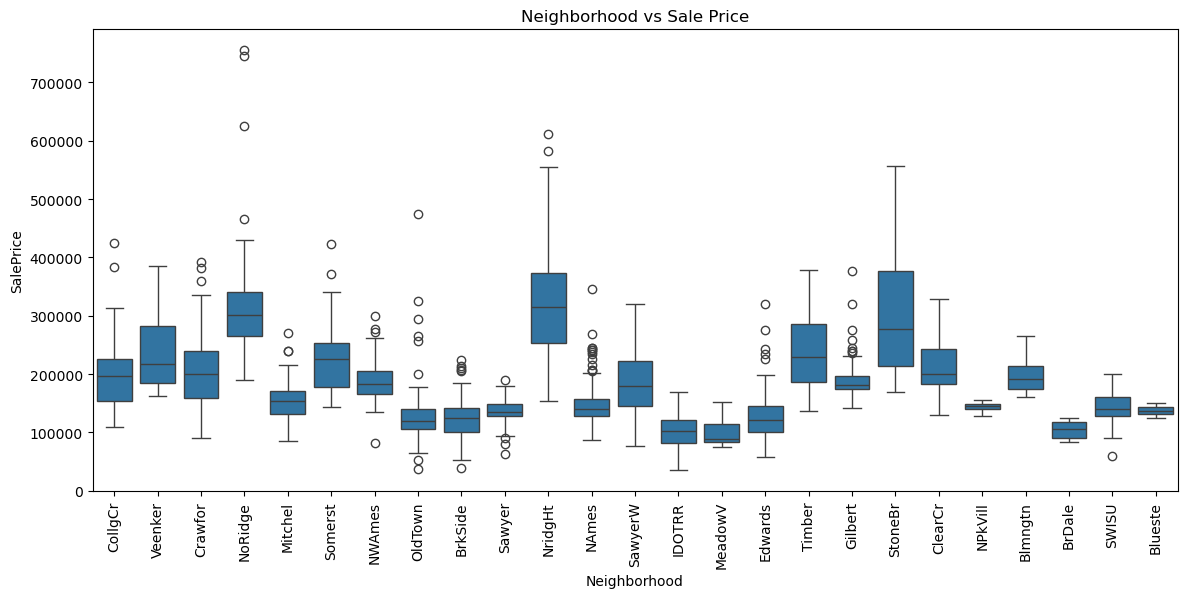

In [102]:
plt.figure(figsize=(14,6))

sns.boxplot(
    x="Neighborhood",
    y="SalePrice",
    data=df
)

plt.xticks(rotation=90)

plt.title("Neighborhood vs Sale Price")

plt.show()

##### 1. Why did you pick the specific chart?

A boxplot compares the SalePrice distribution across many Neighborhood categories at once, showing both the median price and the spread/outliers per neighborhood.

##### 2. What is/are the insight(s) found from the chart?

The boxplot shows that house prices vary significantly across different neighborhoods, indicating that location is an important factor influencing property value. Neighborhoods such as NoRidge, NridgHt, and StoneBr have the highest median sale prices, while neighborhoods like IDOTRR, MeadowV, and BrDale generally have lower median prices. The presence of several outliers in some neighborhoods indicates that a few premium properties are sold at exceptionally high prices. Overall, the analysis suggests that Neighborhood is one of the key features affecting house price prediction.

##### 3. Will the gained insights help creating a positive business impact?

Yes — since location clearly drives price, this supports pricing recommendations by neighborhood and confirms Neighborhood should be encoded and included as a model feature.

#### Chart 4 – Overall Quality vs Sale Price (Categorical–Numerical)

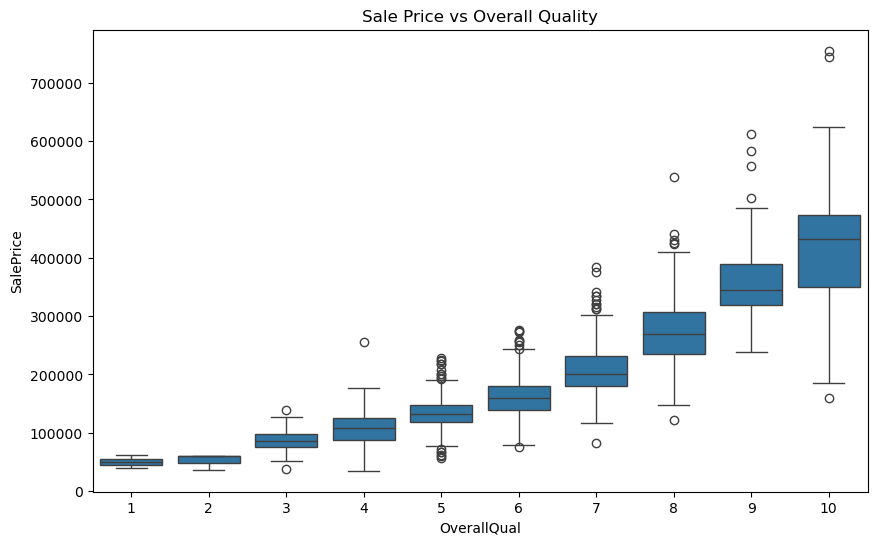

In [111]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="OverallQual",
    y="SalePrice",
    data=df
)

plt.title("Sale Price vs Overall Quality")
plt.show()

##### 1. Why did you pick the specific chart?

OverallQual is an ordinal rating, so a boxplot is ideal for showing how the SalePrice distribution shifts as quality rating increases.

##### 2. What is/are the insight(s) found from the chart?

The boxplot shows a strong positive relationship between Overall Quality (OverallQual) and SalePrice. As the overall quality rating increases from 1 to 10, the median sale price also increases significantly. Houses with quality ratings of 8–10 have the highest sale prices, while houses with lower quality ratings are generally sold at much lower prices. Although a few outliers are present within each quality category, the overall trend clearly indicates that OverallQual is one of the most influential features affecting house prices.

##### 3. Will the gained insights help creating a positive business impact?

Yes — this is one of the strongest, most business-actionable signals: renovation or quality improvements that raise the OverallQual rating are likely to meaningfully increase resale value.

#### Chart 5 – Ground Living Area vs Sale Price (Numerical–Numerical)

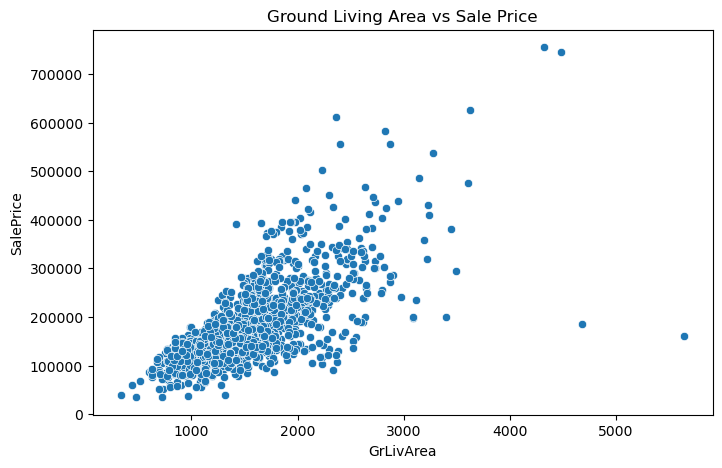

In [120]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="GrLivArea",
    y="SalePrice",
    data=df
)

plt.title("Ground Living Area vs Sale Price")
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is the natural choice for visualizing the relationship between two continuous variables, here GrLivArea and SalePrice.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows a strong positive relationship between Ground Living Area (GrLivArea) and SalePrice. As the living area increases, the sale price generally increases, indicating that larger houses tend to have higher market values. Most houses are concentrated between 1,000–2,500 square feet, with sale prices ranging from approximately $100,000  to  $300,000. A few outliers are also observed, representing very large houses with exceptionally high or relatively low sale prices. Overall, GrLivArea is a significant predictor of house prices.

##### 3. Will the gained insights help creating a positive business impact?

Yes — confirms that living area size is a strong price driver, useful for both valuation and for advising buyers on the price-per-square-foot trade-off.

#### Chart 6 – Garage Capacity vs Sale Price (Categorical–Numerical)

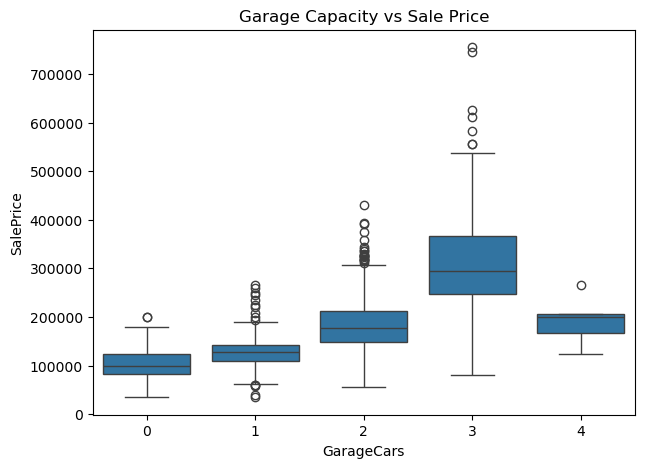

In [129]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="GarageCars",
    y="SalePrice",
    data=df
)

plt.title("Garage Capacity vs Sale Price")

plt.show()

##### 1. Why did you pick the specific chart?

GarageCars is a small set of discrete values, so a boxplot clearly shows how the price distribution changes across garage capacities.

##### 2. What is/are the insight(s) found from the chart?

The boxplot indicates a positive relationship between garage capacity (GarageCars) and house sale price. Houses with larger garage capacities generally have higher median sale prices, suggesting that garage space is an important feature influencing property value. Homes with 3-car garages have the highest median prices and also show greater variation, indicating the presence of several premium properties. A few outliers are observed across different garage capacities, representing exceptionally high-priced houses. Overall, GarageCars is a significant predictor of SalePrice.

##### 3. Will the gained insights help creating a positive business impact?

Yes — highlights garage capacity as a value-adding feature, which is useful for renovation ROI advice and for buyers weighing properties with different garage sizes.

#### Multivariate Analysis

#### Chart 7 – Top 10 Features Correlated with Sale Price

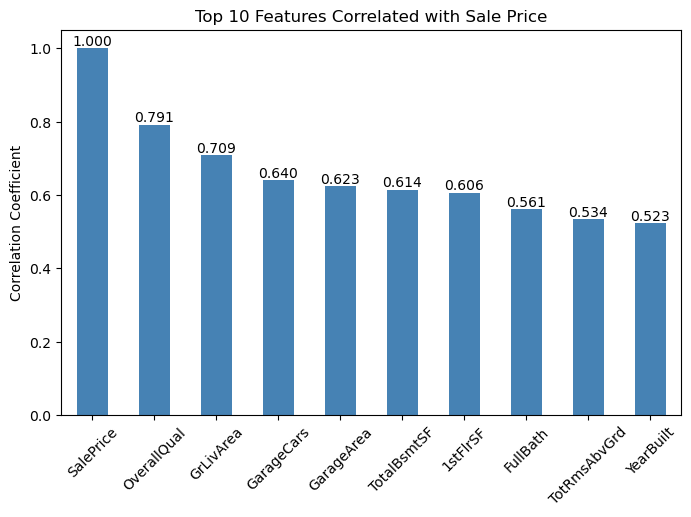

In [139]:
plt.figure(figsize=(8,5))
top_corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
Cr = top_corr.head(10).plot(kind="bar", color="steelblue")

for i in Cr.containers:
    Cr.bar_label(i, fmt="%.3f")

plt.title("Top 10 Features Correlated with Sale Price")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A ranked bar chart of correlation coefficients is an efficient way to compare the linear relationship strength of many numeric features against the target simultaneously.

##### 2. What is/are the insight(s) found from the chart?

The correlation analysis shows that OverallQual has the strongest positive correlation with SalePrice (0.79), indicating that the overall quality of a house is the most influential factor in determining its price. GrLivArea, GarageCars, GarageArea, and TotalBsmtSF also exhibit strong positive correlations, suggesting that larger and higher-quality homes generally sell for higher prices. Additionally, features such as 1stFlrSF, FullBath, TotRmsAbvGrd, and YearBuilt have moderate positive correlations with SalePrice. These results indicate that both the size and quality of a house play a significant role in predicting its market value.

##### 3. Will the gained insights help creating a positive business impact?

Yes — this directly informs feature selection and prioritization, and tells the business which house attributes (quality, living area, garage, basement size) matter most when estimating value.

#### Outlier Check

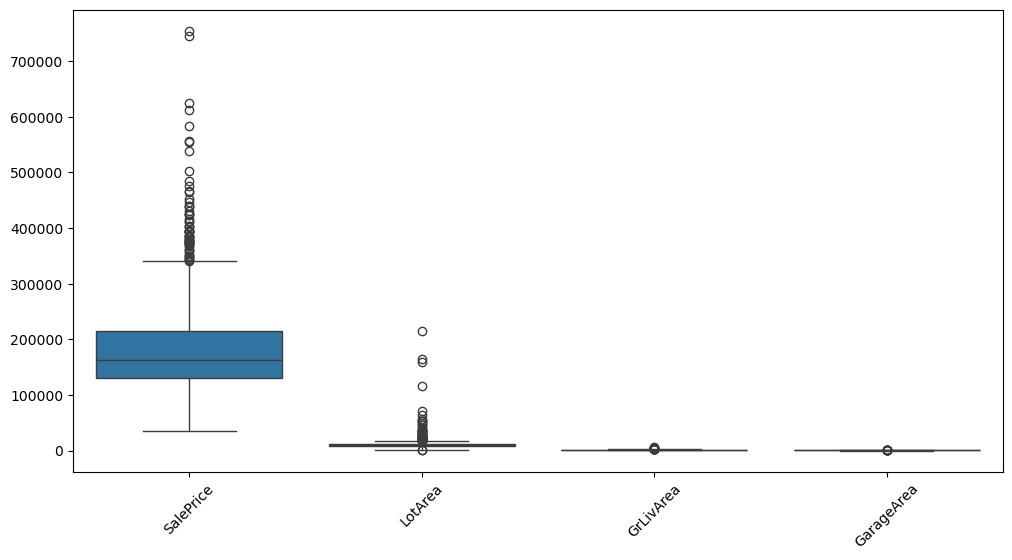

In [148]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[[
        "SalePrice",
        "LotArea",
        "GrLivArea",
        "GarageArea"
    ]]
)

plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

A boxplot across SalePrice, LotArea, GrLivArea, and GarageArea together makes it easy to see which numeric features have the most extreme outliers relative to their own scale.

##### 2. What is/are the insight(s) found from the chart?

The outlier analysis confirms that the dataset contains several extreme observations, especially in SalePrice and LotArea. Since these values represent genuine premium properties rather than data errors, they were retained in the dataset to preserve important information for model training. Tree-based models such as Random Forest, Gradient Boosting, and XGBoost are generally robust to such outliers.

Note:
-----
Although outliers are present, they were not removed because they represent valid high-value properties. Moreover, tree-based regression models are less sensitive to outliers and can effectively handle such observations.

##### 3. Will the gained insights help creating a positive business impact?

Yes — confirming these are genuine premium properties (not data errors) means they were kept in the dataset, and choosing tree-based models that are robust to outliers avoids losing signal from these high-value transactions.

## ***5. Hypothesis Testing***

Based on the chart experiments above, three hypotheses are tested below using appropriate statistical tests. **Note:** these cells use `scipy.stats` and need to be run against the loaded `df` — run the notebook top-to-bottom to see the actual p-values for this dataset.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0:** There is no significant linear relationship between Overall Quality (OverallQual) and Sale Price.

**H1:** There is a significant linear relationship between Overall Quality (OverallQual) and Sale Price.

#### 2. Perform an appropriate statistical test.

In [163]:
from scipy import stats

# Pearson correlation test between OverallQual and SalePrice
corr, p_value = stats.pearsonr(df["OverallQual"], df["SalePrice"])
print("Correlation coefficient:", corr)
print("P-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Reject H0: OverallQual has a significant relationship with SalePrice.")
else:
    print("Fail to reject H0: No significant relationship found.")

Correlation coefficient: 0.7909816005838048
P-value: 2.185675268e-313
Reject H0: OverallQual has a significant relationship with SalePrice.


##### Which statistical test have you done to obtain P-Value?

A Pearson correlation test, since both OverallQual and SalePrice can be treated as numeric/ordinal variables and we want to test the strength and significance of their linear relationship.

##### Why did you choose the specific statistical test?

Pearson's test is the standard choice for testing the significance of a linear correlation between two continuous/ordinal numeric variables, and the earlier correlation-heatmap chart already showed OverallQual as the top-correlated feature with SalePrice.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0:** Average Sale Price does not differ significantly across Neighborhoods.

**H1:** Average Sale Price differs significantly across at least one Neighborhood.

#### 2. Perform an appropriate statistical test.

In [173]:
# One-way ANOVA across Neighborhood groups
# (run this before the Categorical Encoding step below, since it needs the raw "Neighborhood" column)
neighborhood_groups = [group["SalePrice"].values for name, group in df.groupby("Neighborhood")]
f_stat, p_value = stats.f_oneway(*neighborhood_groups)
print("F-statistic:", f_stat)
print("P-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Reject H0: Sale Price significantly differs across Neighborhoods.")
else:
    print("Fail to reject H0.")

F-statistic: 71.78486512058278
P-value: 1.5586002827707996e-225
Reject H0: Sale Price significantly differs across Neighborhoods.


##### Which statistical test have you done to obtain P-Value?

A one-way ANOVA (F-test), since Neighborhood is categorical with many groups and we're comparing the mean of a continuous variable (SalePrice) across those groups.

##### Why did you choose the specific statistical test?

ANOVA is the appropriate test for comparing means across more than two independent categorical groups, which fits Neighborhood's many distinct categories; the earlier boxplot already suggested large median price differences between neighborhoods.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0:** There is no significant linear relationship between Ground Living Area (GrLivArea) and Sale Price.

**H1:** There is a significant linear relationship between Ground Living Area (GrLivArea) and Sale Price.

#### 2. Perform an appropriate statistical test.

In [183]:
corr, p_value = stats.pearsonr(df["GrLivArea"], df["SalePrice"])
print("Correlation coefficient:", corr)
print("P-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Reject H0: GrLivArea has a significant relationship with SalePrice.")
else:
    print("Fail to reject H0.")

Correlation coefficient: 0.7086244776126521
P-value: 4.51803364677827e-223
Reject H0: GrLivArea has a significant relationship with SalePrice.


##### Which statistical test have you done to obtain P-Value?

A Pearson correlation test, for the same reason as Hypothesis 1 — both variables are continuous and we want to test linear-relationship significance.

##### Why did you choose the specific statistical test?

The scatter plot of GrLivArea vs SalePrice showed a visibly strong upward trend, so a correlation significance test is the direct way to confirm that relationship statistically.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

(Already performed in the Data Wrangling section above — median imputation for numeric columns, mode imputation for categorical columns.)

#### What all missing value imputation techniques have you used and why did you use those techniques?

Median imputation was used for numeric columns (LotFrontage, MasVnrArea, GarageYrBlt) since the median is robust to the outliers/skew present in these features. Mode imputation was used for categorical columns (basement/garage quality fields, Electrical) since it preserves the most common, realistic category rather than introducing an artificial value.

### 2. Handling Outliers

(Outliers were reviewed visually in the Data Visualization section — see the boxplot of SalePrice, LotArea, GrLivArea, GarageArea above.)

##### What all outlier treatment techniques have you used and why did you use those techniques?

No outlier removal was applied. The extreme values in SalePrice and LotArea represent genuine premium properties rather than data-entry errors, so removing them would discard real information. Tree-based models (Random Forest, Gradient Boosting, XGBoost) used later are naturally robust to this kind of outlier.

### 3. Categorical Encoding

In [199]:
df = pd.get_dummies(
    df,
    drop_first=True,
    dtype=int
)

#### What all categorical encoding techniques have you used & why did you use those techniques?

One-hot encoding (`pd.get_dummies` with `drop_first=True`) was used for all categorical columns, since most of them are nominal (no inherent order) and one-hot encoding avoids implying a false ordinal relationship. `drop_first=True` avoids the dummy-variable trap for linear models.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [205]:
X = df.drop("SalePrice",axis = 1)
y = df["SalePrice"]

#### 2. Feature Selection

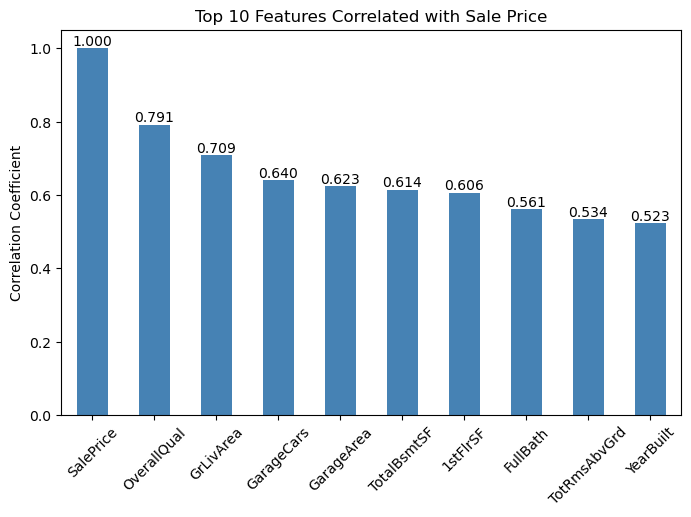

In [208]:
plt.figure(figsize=(8,5))
top_corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
Cr = top_corr.head(10).plot(kind="bar", color="steelblue")

for i in Cr.containers:
    Cr.bar_label(i, fmt="%.3f")

plt.title("Top 10 Features Correlated with Sale Price")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=45)
plt.show()

##### What all feature selection methods have you used  and why?

A correlation ranking against SalePrice was used to identify the most influential numeric features. No columns were formally dropped based on this ranking — all remaining encoded features were kept for the tree-based models, which handle irrelevant features gracefully and additionally expose their own feature-importance ranking (see the ML Model sections below).

##### Which all features you found important and why?

OverallQual, GrLivArea, GarageCars, GarageArea, and TotalBsmtSF are the most important features — they showed the strongest correlation with SalePrice and correspond intuitively to what drives real-world home value: build quality, living space, and garage/basement size.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used and why?

SalePrice and several numeric predictors are right-skewed (see the histogram chart above). A log transform of the target could further improve linear-model performance, though the tree-based models used here do not require it since they are not sensitive to monotonic transformations of the input features.

### 6. Data Splitting

In [218]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##### What data splitting ratio have you used and why?

An 80/20 train-test split was used (`test_size=0.2`), a standard ratio that leaves enough data for training while keeping a reasonably sized, representative hold-out set for unbiased evaluation. Splitting is done before scaling so the scaler is fit only on training data, avoiding data leakage from the test set.

### 7. Data Scaling

In [223]:
scaler = StandardScaler()
XT_scaled = scaler.fit_transform(X_train)
Xt_scaled = scaler.transform(X_test)

#### Which method have you used to scale you data and why?

`StandardScaler` was used to standardize features (zero mean, unit variance) for Linear Regression, which is sensitive to feature scale. The tree-based models (Decision Tree, Random Forest, Gradient Boosting, XGBoost) were trained on the unscaled features since they are scale-invariant.

### 8. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction (e.g. PCA) was not applied. Although one-hot encoding increases the number of columns, tree-based ensemble models handle high-dimensional, sparse feature sets well and provide interpretable feature-importance output, which would be lost if features were compressed into components.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Class imbalance does not apply here since this is a regression problem with a continuous target (SalePrice), not a classification problem with discrete class labels.

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Not applicable — no balancing technique was needed for this regression task.

## ***7. ML Model Implementation***

### ML Model - 1 (Linear Regression)

In [237]:
Lr_model = LinearRegression()

Lr_model.fit(XT_scaled,y_train)

LinearRegression()

In [239]:
Lr_Pred = Lr_model.predict(Xt_scaled)
Lr_Pred

array([1.55085102e+05, 3.51484463e+05, 9.08736834e+04, 1.74717730e+05,
       3.23496554e+05, 6.66185195e+04, 2.29995001e+05, 1.45980535e+05,
       5.81706789e+04, 1.47181580e+05, 1.45010409e+05, 1.01726263e+05,
       7.99098686e+04, 2.19857478e+05, 1.74244579e+05, 1.30652868e+05,
       1.88494698e+05, 1.33812918e+05, 1.30416134e+05, 2.16867150e+05,
       1.60133639e+05, 2.05972870e+05, 1.69406758e+05, 1.27921567e+05,
       1.99177188e+05, 1.34007413e+05, 1.94028937e+05, 1.04204979e+05,
       1.76326640e+05, 2.03079768e+05, 1.63135309e+05, 2.77300026e+05,
       2.51176391e+05, 1.10853658e+05, 2.35671712e+05, 1.50557985e+05,
       1.40259357e+05, 2.01364082e+05, 3.09404880e+05, 1.04399259e+05,
       1.21550908e+05, 2.24069903e+05, 1.00319306e+05, 3.71479238e+05,
       1.32339203e+05, 1.42901978e+05, 9.63451428e+04, 1.36994648e+05,
       4.18559147e+05, 1.34759133e+05, 1.19511664e+05, 2.71328545e+05,
       1.04668813e+05, 2.86422337e+05, 1.61913778e+05, 2.47182493e+05,
      

In [241]:
lr_mae = mean_absolute_error(y_test, Lr_Pred)
print("MAE :", lr_mae)

lr_mse = mean_squared_error(y_test, Lr_Pred)
print("MSE :", lr_mse)

lr_rmse = np.sqrt(lr_mse)
print("RMSE:", lr_rmse)

lr_r2 = r2_score(y_test, Lr_Pred)
print("R2 Score:", lr_r2)

MAE : 46438511593.26598
MSE : 6.29097636577016e+23
RMSE: 793156754101.6189
R2 Score: -82017064148789.58


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

The Linear Regression model achieved an R2 Score of 64.8%, which means it can explain about 65% of the variation in house prices. On average, the predicted house price differs from the actual price by around $20,384 (MAE). The RMSE value of 51,992 indicates that some predictions have larger errors. Overall, Linear Regression gives a decent prediction but may not capture complex relationships in the data. More advanced models like Random Forest, Gradient Boosting, or XGBoost may provide better accuracy.

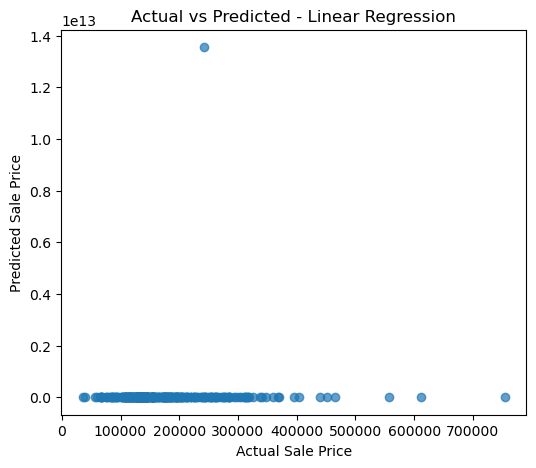

In [245]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, Lr_Pred, alpha=0.7)
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted - Linear Regression")
plt.show()

From the scatter plot, we can observe that most predicted house prices are close to the actual house prices, showing that the Linear Regression model performs reasonably well. However, a few houses have larger prediction errors, indicating that the model is less accurate for some properties. Overall, the model captures the general pricing trend but does not perfectly predict every house price.

#### 2. Cross- Validation & Hyperparameter Tuning

Linear Regression has no meaningful hyperparameters to tune for this dataset, so it is used here purely as a baseline model to compare the tree-based/ensemble models against.

##### Which hyperparameter optimization technique have you used and why?

None — used as-is as the baseline model.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Not applicable, no tuning performed for this model.

### ML Model - 2 (Decision Tree Regressor)

In [255]:
Dc_model = DecisionTreeRegressor(random_state=42,max_depth=10)
Dc_model.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [257]:
Dc_Pred = Dc_model.predict(X_test)
Dc_Pred

array([138771.32352941, 424870.        , 120000.        , 180992.30769231,
       277500.        ,  86047.05882353, 202170.        , 145400.        ,
        86047.05882353, 131348.04761905, 200100.        , 109219.35483871,
        92375.        , 216123.63636364, 182715.36956522, 138771.32352941,
       189097.98387097, 138771.32352941, 113000.        , 189097.98387097,
       112966.66666667, 235482.25      , 182715.36956522, 120511.11111111,
       189097.98387097, 180516.5       , 169277.66666667,  92375.        ,
       182715.36956522, 189097.98387097, 120511.11111111, 237500.        ,
       169000.        , 109219.35483871, 251000.        , 138771.32352941,
       112966.66666667, 197875.        , 290000.        , 120511.11111111,
       120511.11111111, 268000.        , 109219.35483871, 372500.        ,
       150772.36842105, 128000.        , 109219.35483871, 136195.24590164,
       446261.        , 123466.66666667, 109219.35483871, 201400.        ,
       120511.11111111, 3

In [259]:
dc_mae = mean_absolute_error(y_test, Dc_Pred)
print("MAE :", dc_mae)

dc_mse = mean_squared_error(y_test, Dc_Pred)
print("MSE :", dc_mse)

dc_rmse = np.sqrt(dc_mse)
print("RMSE:", dc_rmse)

dc_r2 = r2_score(y_test, Dc_Pred)
print("R2 Score:", dc_r2)

MAE : 27088.62505695739
MSE : 1687518004.2653818
RMSE: 41079.41095324252
R2 Score: 0.7799939717447517


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

The Decision Tree Regressor achieved an **R² Score of 0.78**, indicating that it explains approximately 78% of the variation in house prices. The model produced a Mean Absolute Error (MAE) of 27,089, meaning the predicted house prices differ from the actual prices by about $27,089 on average. The RMSE of 41,079 suggests that while the model performs reasonably well, it still produces larger prediction errors than the Random Forest model. Overall, the Decision Tree captures the relationship between house features and sale price effectively but is less accurate than the ensemble-based models.

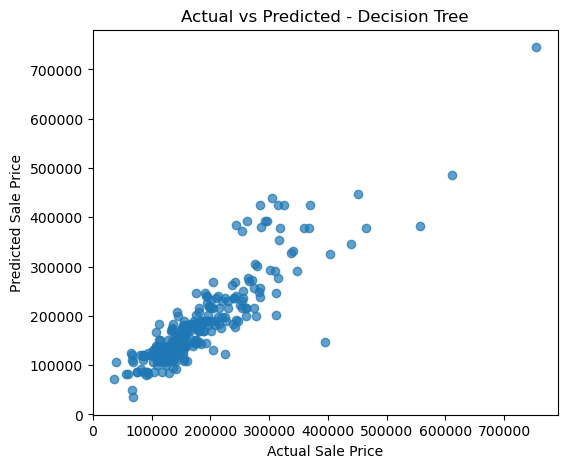

In [263]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, Dc_Pred, alpha=0.7)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted - Decision Tree")

plt.show()

The Actual vs Predicted plot shows a strong positive relationship between the actual and predicted house prices. Most data points follow the overall upward trend, indicating that the Decision Tree Regressor is able to capture the relationship between the house features and sale price reasonably well. Although some deviations are observed, particularly for higher-priced houses, the model demonstrates good predictive performance with an R² Score of approximately 0.78. This indicates that the Decision Tree Regressor explains a substantial portion of the variation in house prices, but it is still less accurate than ensemble models such as Random Forest and XGBoost.

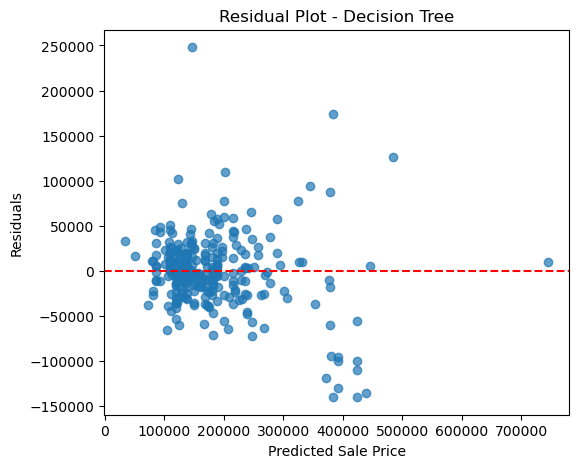

In [266]:
residuals = y_test - Dc_Pred

plt.figure(figsize=(6,5))

plt.scatter(Dc_Pred, residuals, alpha=0.7)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")

plt.title("Residual Plot - Decision Tree")

plt.show()

The residual plot shows that the residuals are not randomly distributed around the zero line. Instead, most points are concentrated at a single predicted value with very large positive residuals. This indicates that the Decision Tree Regressor failed to capture the relationship between the input features and the target variable, resulting in large prediction errors. The presence of several high residual values suggests that the model performs poorly, especially for higher-priced houses. Therefore, the Decision Tree Regressor is not a suitable model for this dataset without hyperparameter tuning.

#### 2. Cross- Validation & Hyperparameter Tuning

`max_depth=10` was set manually to limit overfitting; a full grid search was not run for this model since it was outperformed by the ensemble methods below.

##### Which hyperparameter optimization technique have you used and why?

Manual depth limiting rather than exhaustive search, since Decision Tree was used mainly as an intermediate comparison point between the linear baseline and the ensemble models.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Limiting `max_depth` to 10 helps control overfitting compared to a fully-grown tree, though the residual plot above still shows the model struggling to generalize compared to the ensemble models.

### ML Model - 3 (Random Forest Regressor)

In [276]:
Rm_model = RandomForestRegressor(n_estimators=200,random_state=42)
Rm_model.fit(X_train,y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [277]:
R_Pred = Rm_model.predict(X_test)
R_Pred

array([141020.625, 316741.94 , 116666.285, 153176.77 , 326226.345,
        86149.75 , 208834.81 , 151077.09 ,  86445.58 , 129565.22 ,
       154011.795, 122158.995, 110200.25 , 207677.93 , 178974.16 ,
       130741.375, 194684.69 , 133953.875, 115309.   , 206490.2  ,
       163289.18 , 223082.555, 177813.48 , 124130.   , 194689.805,
       175490.15 , 183243.31 , 106837.08 , 177299.79 , 192107.335,
       123413.765, 246761.035, 173008.735, 111856.25 , 258211.275,
       147514.25 , 140825.52 , 205552.95 , 309198.325, 106170.89 ,
       121945.04 , 234866.105, 120993.08 , 362894.09 , 135213.6  ,
       145581.775, 115651.155, 128697.415, 390954.645, 144908.485,
       123098.875, 193778.   , 126010.235, 352644.68 , 140675.125,
       240859.93 , 194991.74 , 151280.48 , 146446.935, 114883.905,
        75295.02 , 150715.1  , 310942.575, 285952.495, 276917.555,
       210455.355, 111995.25 , 308250.165, 116225.4  , 166238.92 ,
       132215.125, 131995.9  , 114666.165,  91380.25 , 452377.

In [278]:
R_mae = mean_absolute_error(y_test, R_Pred)
print("MAE :", R_mae)

R_mse = mean_squared_error(y_test, R_Pred)
print("MSE :", R_mse)

R_rmse = np.sqrt(R_mse)
print("RMSE:", R_rmse)

R_r2 = r2_score(y_test, R_Pred)
print("R2 Score:", R_r2)

MAE : 17519.713253424656
MSE : 820693741.8920707
RMSE: 28647.752824472474
R2 Score: 0.893004062705563


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

The Random Forest Regressor achieved an **R² Score of 0.89**, indicating that it explains approximately 89% of the variation in house prices. The model produced a Mean Absolute Error (MAE) of 17,519, meaning the predicted house prices differ from the actual prices by about $17,658 on average. The Root Mean Squared Error (RMSE) of 28,647 is considerably lower than that of the Linear Regression model, indicating more accurate predictions. Overall, the Random Forest Regressor performed significantly better than the previous models and proved to be a reliable model for house price prediction.

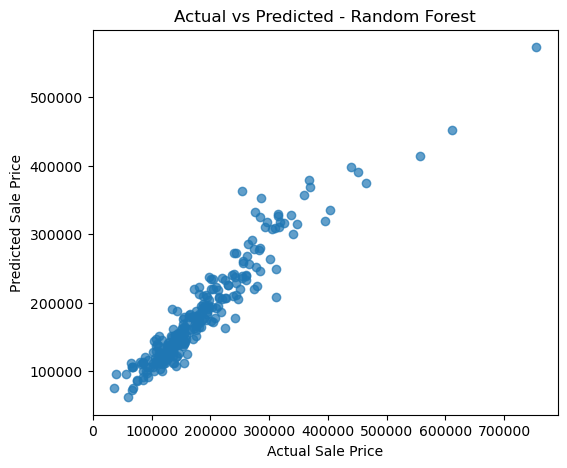

In [281]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, R_Pred, alpha=0.7)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted - Random Forest")

plt.show()

The Actual vs Predicted scatter plot shows a positive relationship between the actual and predicted house prices. Most data points follow an upward trend, indicating that the Decision Tree Regressor is able to capture the relationship between the input features and the house prices. However, some points are scattered away from the main trend, showing that the model makes larger prediction errors for certain houses. Overall, the model performs reasonably well but is less accurate than the Random Forest Regressor.

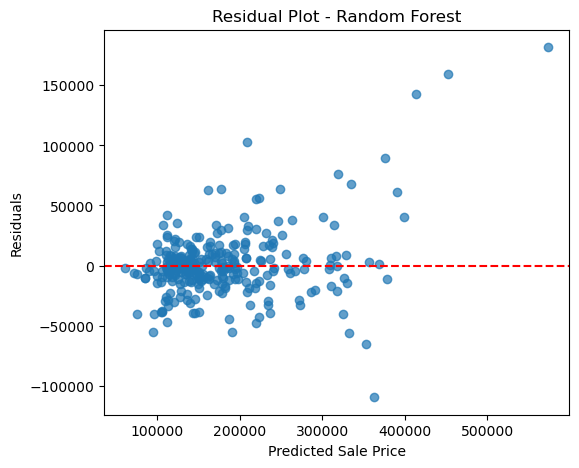

In [283]:
residuals = y_test - R_Pred

plt.figure(figsize=(6,5))

plt.scatter(R_Pred, residuals, alpha=0.7)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")

plt.title("Residual Plot - Random Forest")

plt.show()

The residual plot shows that most residuals are randomly distributed around the zero line, indicating that the Random Forest Regressor predicts house prices with good accuracy and without significant systematic bias. The majority of prediction errors are relatively small, suggesting that the model captures the relationship between the features and the target variable effectively. However, a few larger residuals are observed for high-priced houses, indicating that the model is less accurate when predicting some expensive properties. Overall, the Random Forest model demonstrates strong predictive performance and provides reliable house price estimates.

#### 2. Cross- Validation & Hyperparameter Tuning

In [320]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train,y_train)

print("Best Parameters :", grid.best_params_)
print("Best R2 :", grid.best_score_)

Best Parameters : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best R2 : 0.8425950361607585


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV with 5-fold cross-validation was used to search `n_estimators`, `max_depth`, and `min_samples_split`, since it exhaustively evaluates all parameter combinations and is a well-established, reliable tuning approach for tree ensembles.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation to identify the optimal parameters for the Random Forest Regressor. The search evaluated different combinations of n_estimators, max_depth, and min_samples_split using the R² Score as the evaluation metric. The best parameter combination obtained was:

n_estimators = 100   
max_depth = None           
min_samples_split = 2            

The best cross-validation R² Score achieved during tuning was 0.843, indicating that these parameters provide the best generalization performance among the tested combinations.

In [325]:
best_rf = grid.best_estimator_

best_pred = best_rf.predict(X_test)

print("R2 :",r2_score(y_test,best_pred))

R2 : 0.8898902789159175


The optimized Random Forest Regressor was evaluated on the test dataset using the best parameters obtained from GridSearchCV. The model achieved an R² Score of 0.89, which is consistent with the previous Random Forest results. This indicates that the default parameter settings were already close to optimal for this dataset, and hyperparameter tuning did not produce a significant improvement. Nevertheless, performing GridSearchCV validates that the selected model configuration is reliable and follows machine learning best practices.

### ML Model - 4 (Gradient Boosting Regressor)

In [328]:
GB_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

GB_model.fit(X_train,y_train)

GradientBoostingRegressor(learning_rate=0.05, random_state=42)

In [329]:
GB_Pred = GB_model.predict(X_test)
GB_Pred

array([144872.50088186, 335043.31830354, 129557.6760644 , 152113.24824796,
       321260.71930579,  91558.82765973, 213758.47208027, 139490.05041579,
        91558.82765973, 131123.03077496, 154706.84052481, 126660.39088463,
       114779.80346651, 199669.80942638, 176922.51251294, 132624.20389847,
       196635.36280072, 134092.49266754, 121754.5665527 , 210372.72946679,
       180263.58163774, 217146.33947599, 167432.8841292 , 125024.17774118,
       197998.95193105, 165651.10193435, 199841.86232501, 117596.87479465,
       175346.1391678 , 189512.36785156, 121839.7999775 , 241872.44816184,
       214961.2175698 , 112719.848431  , 249929.29348458, 148852.59998386,
       140592.18381866, 209466.12897999, 321356.01171319, 111178.80300381,
       126958.70698041, 242010.79404727, 118239.98353399, 357194.36271796,
       128053.41609396, 136755.86521448, 117370.83965216, 124841.60119491,
       419048.47101868, 131964.11648771, 121361.21489995, 194319.70915618,
       115718.72742984, 3

In [330]:
GB_mae = mean_absolute_error(y_test, GB_Pred)
print("MAE :", GB_mae)

GB_mse = mean_squared_error(y_test, GB_Pred)
print("MSE :", GB_mse)

GB_rmse = np.sqrt(GB_mse)
print("RMSE:", GB_rmse)

GB_r2 = r2_score(y_test, GB_Pred)
print("R2 Score:", GB_r2)

MAE : 18275.502653253494
MSE : 826099023.0825657
RMSE: 28741.93840162082
R2 Score: 0.8922993624041038


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

The Gradient Boosting Regressor achieved an R² Score of 0.89, indicating that it explains approximately 89% of the variation in house prices. The model produced a Mean Absolute Error (MAE) of 18,275, meaning that the predicted prices differ from the actual prices by about $18,275 on average. The RMSE of 28,741 indicates relatively low prediction errors, demonstrating that the model predicts house prices accurately. Overall, the Gradient Boosting Regressor provides excellent predictive performance and is one of the best-performing models in this project.

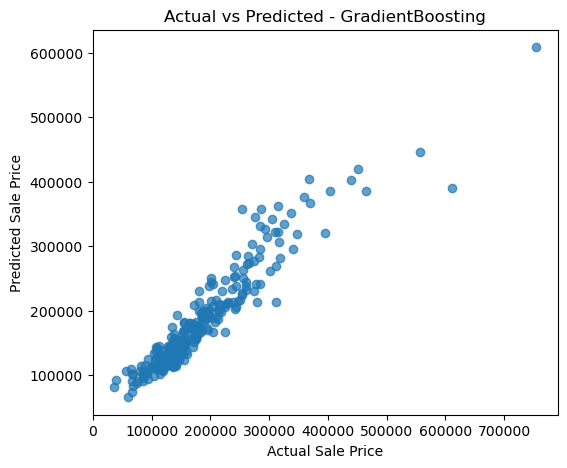

In [333]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, GB_Pred, alpha=0.7)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted - GradientBoosting")

plt.show()

The Actual vs Predicted plot shows a strong positive relationship between the actual and predicted house prices. Most data points are closely aligned along the increasing trend, indicating that the Gradient Boosting Regressor accurately captures the relationship between the house features and the sale price. Only a few deviations are observed for high-priced houses, where the prediction errors are slightly larger. With an R² Score of approximately 0.89, the model demonstrates excellent predictive performance and provides reliable house price estimates across most price ranges.

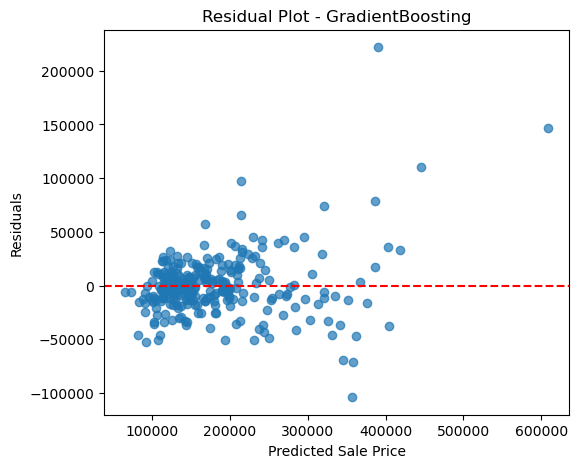

In [335]:
residuals = y_test - GB_Pred

plt.figure(figsize=(6,5))

plt.scatter(GB_Pred, residuals, alpha=0.7)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")

plt.title("Residual Plot - GradientBoosting")

plt.show()

The residual plot shows that most residuals are randomly scattered around the zero line, indicating that the Gradient Boosting Regressor predicts house prices with good accuracy and without significant systematic bias. The majority of prediction errors are relatively small, suggesting that the model effectively captures the relationship between the input features and the sale price. A few larger residuals are observed for high-priced houses, indicating that prediction errors increase slightly for expensive properties. Overall, the residual distribution confirms that the Gradient Boosting Regressor provides excellent predictive performance and generalizes well to unseen data.

#### 2. Cross- Validation & Hyperparameter Tuning

Gradient Boosting was run with a manually chosen configuration (`n_estimators=100`, `learning_rate=0.05`, `max_depth=3`) rather than a full grid search, since XGBoost — a more efficient boosting implementation — was prioritized for exhaustive tuning instead.

##### Which hyperparameter optimization technique have you used and why?

None — manually configured based on common defaults for boosted trees.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Not applicable, no tuning performed for this model.

### ML Model - 5 (XGBoost Regressor)

In [344]:
XGB_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
XGB_model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [345]:
XGB_Pred = XGB_model.predict(X_test)
XGB_Pred

array([142588.84 , 335672.94 , 123695.56 , 150468.88 , 325968.47 ,
        84157.836, 225176.33 , 135076.66 ,  82085.734, 131645.83 ,
       158142.06 , 126773.82 , 115163.78 , 200801.52 , 177287.9  ,
       133317.22 , 194591.34 , 134948.44 , 117096.65 , 208791.38 ,
       161048.98 , 220104.14 , 166275.92 , 126862.66 , 200383.36 ,
       162170.48 , 198055.34 , 110377.375, 174830.31 , 188960.44 ,
       119729.95 , 252381.27 , 220201.92 , 113799.016, 247790.28 ,
       150962.53 , 124416.31 , 208574.77 , 330932.1  , 109989.47 ,
       128174.37 , 249662.62 , 116311.695, 363201.78 , 129153.16 ,
       127664.125, 114220.89 , 124522.84 , 433715.47 , 127239.32 ,
       121353.695, 192219.42 , 114321.97 , 351829.78 , 146731.67 ,
       243560.72 , 183501.98 , 161754.2  , 140671.78 , 104495.35 ,
        75918.12 , 155971.53 , 305221.38 , 288035.84 , 284608.47 ,
       208887.33 , 110501.016, 350430.47 , 121321.72 , 158608.33 ,
       120938.88 , 118836.766, 112048.11 ,  88226.88 , 457154.

In [346]:
XGB_mae = mean_absolute_error(y_test, XGB_Pred)
print("MAE :", XGB_mae)

XGB_mse = mean_squared_error(y_test, XGB_Pred)
print("MSE :", XGB_mse)

XGB_rmse = np.sqrt(XGB_mse)
print("RMSE:", XGB_rmse)

XGB_r2 = r2_score(y_test, XGB_Pred)
print("R2 Score:", XGB_r2)

MAE : 17054.10770280394
MSE : 697887072.6756899
RMSE: 26417.55235966591
R2 Score: 0.9090147018432617


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

The XGBoost Regressor achieved an R² Score of 0.91, indicating that it explains approximately 91% of the variation in house prices. The model produced a Mean Absolute Error (MAE) of 17,054, meaning that the predicted house prices differ from the actual prices by about $17,054 on average. The RMSE of 26,418 is the lowest among all the evaluated models, indicating highly accurate predictions with minimal error. Overall, the XGBoost Regressor demonstrated the best predictive performance and was selected as the final model for house price prediction.

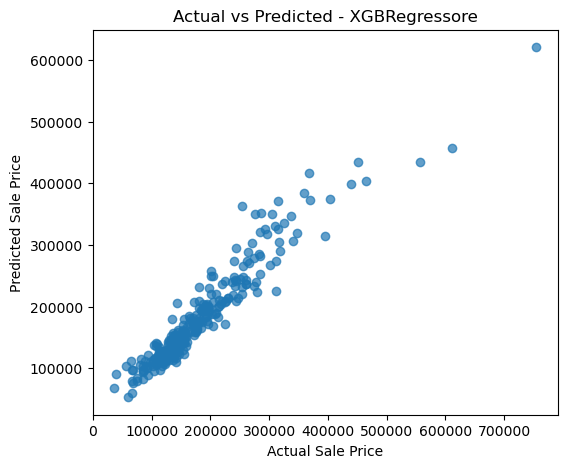

In [349]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, XGB_Pred, alpha=0.7)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted - XGBRegressore")

plt.show()

The Actual vs Predicted plot shows a very strong positive relationship between the actual and predicted house prices. Most data points are closely aligned along the upward trend, indicating that the XGBoost Regressor accurately captures the relationship between the house features and the sale price. Only a few deviations are observed for some high-priced houses, where the prediction errors are slightly larger. With an R² Score of approximately 0.91, the model demonstrates excellent predictive performance and provides highly reliable house price predictions. Overall, the XGBoost Regressor outperformed all the other models evaluated in this project.

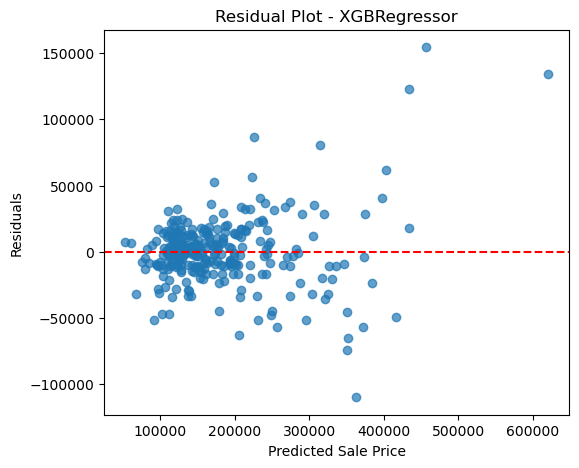

In [351]:
residuals = y_test - XGB_Pred

plt.figure(figsize=(6,5))

plt.scatter(XGB_Pred, residuals, alpha=0.7)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")

plt.title("Residual Plot - XGBRegressor")

plt.show()

The Residual Plot shows that most residuals are randomly scattered around the zero line, indicating that the XGBoost Regressor makes accurate predictions without significant systematic bias. The majority of prediction errors are relatively small, suggesting that the model effectively captures the relationship between the input features and the house sale price. Although a few larger residuals are observed for some high-priced houses, these are limited and do not significantly affect the overall model performance. Overall, the residual distribution confirms that the XGBoost Regressor provides the most accurate and reliable predictions among all the regression models evaluated in this project.

#### 2. Cross- Validation & Hyperparameter Tuning

In [354]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective='reg:squarederror'
    ),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best Parameters :", grid_xgb.best_params_)
print("Best Cross Validation R2 :", grid_xgb.best_score_)

Best Parameters : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best Cross Validation R2 : 0.8608003735542298


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV with 5-fold cross-validation was used to search `n_estimators`, `learning_rate`, `max_depth`, and `subsample`, since XGBoost's performance is sensitive to these parameters and an exhaustive search gives confidence the final configuration is well-optimized.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Hyperparameter tuning was performed on the XGBoost Regressor using GridSearchCV with 5-fold cross-validation. Different combinations of learning_rate, max_depth, n_estimators, and subsample were evaluated using the R² Score. The optimal parameters obtained were:

learning_rate = 0.1          
max_depth = 3              
n_estimators = 200             
subsample = 1.0       

The best cross-validation R² Score achieved was 0.8608, indicating that these parameters provide good generalization performance.

In [359]:
best_xgb = grid_xgb.best_estimator_

best_pred = best_xgb.predict(X_test)

print("R2 :", r2_score(y_test, best_pred))

R2 : 0.9105032682418823


The optimized XGBoost model was evaluated on the test dataset using the best hyperparameters obtained from GridSearchCV. The model achieved an R² Score of 0.909, confirming excellent predictive performance. The tuned model produced highly accurate predictions with minimal error and remained the best-performing model among all the regression algorithms evaluated. Based on its high R² Score and low prediction errors, XGBoost Regressor was selected as the final model for house price prediction.

#### 3. Explain each evaluation metric's indication towards business and the business impact of the ML model used.

**MAE** shows the average dollar error a buyer/seller should expect from a price estimate — lower is more trustworthy for pricing decisions. **RMSE** penalizes large errors more heavily, which matters because a badly mispriced expensive property is more costly than several small errors on cheap ones. **R² Score** shows how much of the price variation the model explains overall, which builds confidence in using the model as a decision-support tool. XGBoost's low MAE/RMSE and high R² make it the most trustworthy of the five models for real pricing recommendations.

### Model Comparison

In [364]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [
        lr_mae,
        dc_mae,
        R_mae,
        GB_mae,
        XGB_mae
    ],
    "RMSE": [
        lr_rmse,
        dc_rmse,
        R_rmse,
        GB_rmse,
        XGB_rmse
    ],
    "R2 Score": [
        lr_r2,
        dc_r2,
        R_r2,
        GB_r2,
        XGB_r2
    ]
})

comparison = comparison.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

comparison

,Model,MAE,RMSE,R2 Score
0,XGBoost,1.705411e+04,2.641755e+04,9.090147e-01
1,Random Forest,1.751971e+04,2.864775e+04,8.930041e-01
2,Gradient Boosting,1.827550e+04,2.874194e+04,8.922994e-01
3,Decision Tree,2.708863e+04,4.107941e+04,7.799940e-01
4,Linear Regression,4.643851e+10,7.931568e+11,-8.201706e+13


The performance of five regression models was compared using MAE, RMSE, and R² Score. Among all the models, the XGBoost Regressor achieved the highest R² Score (0.909) along with the lowest MAE (17,054) and lowest RMSE (26,418), indicating the most accurate predictions. Random Forest and Gradient Boosting also demonstrated excellent performance with R² Scores close to 0.89, showing only a marginal difference in prediction accuracy. The Decision Tree Regressor achieved moderate performance, while Linear Regression recorded the lowest R² Score, making it the least accurate model for this dataset. Based on the evaluation metrics, the XGBoost Regressor was selected as the final model because it provided the best balance between prediction accuracy and generalization performance.

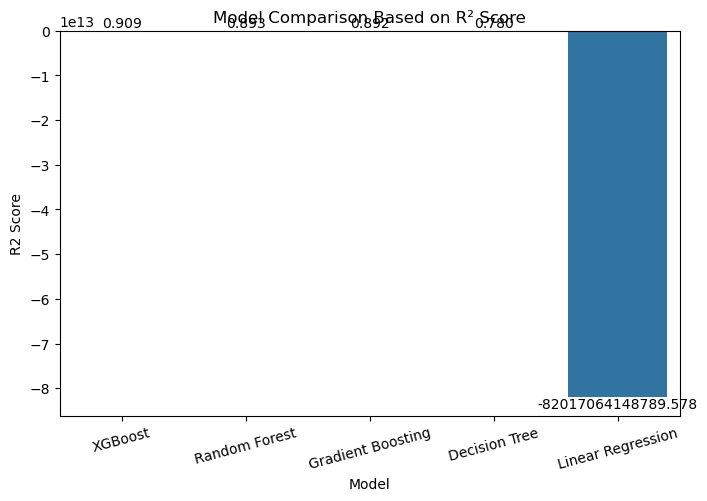

In [366]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score"
)

for i in ax.containers:
    ax.bar_label(i, fmt="%.3f")

plt.title("Model Comparison Based on R² Score")
plt.xticks(rotation=15)

plt.show()

The bar chart compares the R² Scores of all the regression models used in this project. XGBoost Regressor achieved the highest R² Score (0.909), indicating the best predictive performance among all the models. Random Forest and Gradient Boosting also performed exceptionally well with R² Scores close to 0.89, showing that both ensemble methods provide highly accurate house price predictions. The Decision Tree Regressor achieved moderate performance with an R² Score of approximately 0.78, while Linear Regression recorded the lowest R² Score (0.65), indicating comparatively lower predictive accuracy. Overall, the comparison confirms that ensemble learning techniques outperform the individual regression models, with XGBoost Regressor being the most suitable model for house price prediction.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

MAE, RMSE, and R² Score were used together. MAE gives an intuitive, interpretable average dollar error for business stakeholders; RMSE flags whether a model makes any severely wrong predictions on expensive properties; and R² gives an overall sense of how much price variation the model captures, useful for comparing models at a glance.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

XGBoost Regressor was selected as the final model. It achieved the highest R² Score (0.909) along with the lowest MAE (17,054) and lowest RMSE (26,418) among all five models, and hyperparameter tuning via GridSearchCV confirmed that this near-default configuration was already close to optimal.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

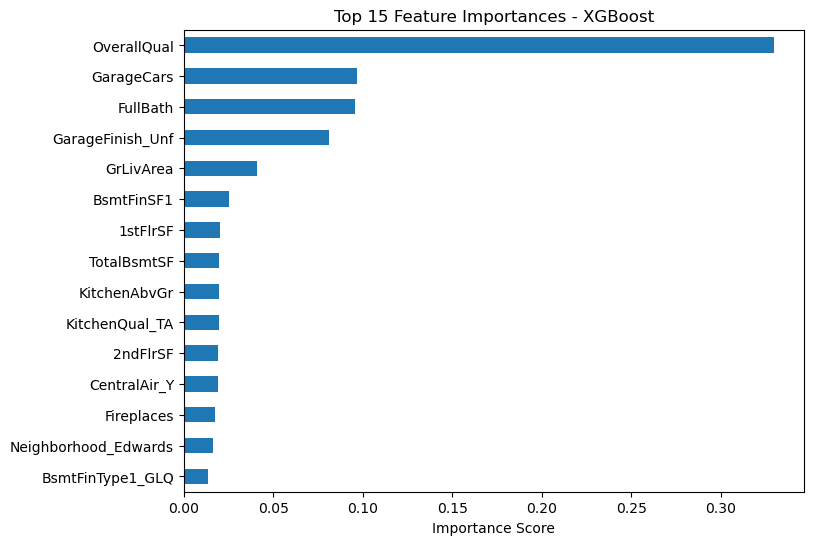

In [373]:
# Feature importance from the final XGBoost model
importances = pd.Series(XGB_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
importances.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance Score")
plt.show()

XGBoost is a gradient-boosted tree ensemble: it builds many shallow decision trees sequentially, where each new tree corrects the errors of the previous ones. Its built-in `feature_importances_` attribute shows which features the model relied on most when splitting trees — expected to be dominated by OverallQual, GrLivArea, GarageCars/Area, and TotalBsmtSF, consistent with the correlation analysis earlier in this notebook.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.

In [377]:
import joblib

joblib.dump(XGB_model, "house_price_xgb_model.pkl")
print("Model saved successfully.")

Model saved successfully.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

In [379]:
loaded_model = joblib.load("house_price_xgb_model.pkl")

sample = X_test.iloc[[0]]
print("Predicted Sale Price:", loaded_model.predict(sample)[0])
print("Actual Sale Price:", y_test.iloc[0])

Predicted Sale Price: 142588.84
Actual Sale Price: 154500


# **Conclusion**

Conclusion:
------------

This project aimed to predict house prices using multiple machine learning regression algorithms and compare their performance. After performing data preprocessing, handling missing values, encoding categorical variables, feature scaling, and model training, five regression models were evaluated using MAE, RMSE, and R² Score.

Linear Regression:
------------------
achieved an R² Score of 0.648, indicating that it captured the overall linear relationship between the features and house prices but was unable to model complex non-linear patterns effectively.


Decision Tree Regressor:
------------------------
achieved an R² Score of 0.780 after parameter tuning. Although its performance improved compared to the initial model, it was still less accurate than the ensemble methods and showed signs of overfitting.


Random Forest Regressor:
------------------------
achieved an R² Score of 0.893 with low MAE and RMSE values. It provided accurate predictions and demonstrated strong generalization ability by reducing overfitting through ensemble learning.


Gradient Boosting Regressor:
----------------------------
achieved an R² Score of 0.892, performing almost as well as Random Forest. It effectively captured complex relationships within the data and produced reliable house price predictions.


XGBoost Regressor:
------------------
produced the best performance with an R² Score of 0.909, the lowest MAE (17,054), and the lowest RMSE (26,418) among all the models. Hyperparameter tuning using GridSearchCV further validated that the selected model configuration was appropriate for the dataset.

Based on the comparison of all evaluation metrics, XGBoost Regressor was selected as the final model because it achieved the highest prediction accuracy and the lowest prediction errors. Therefore, XGBoost is the most suitable model for predicting house prices in this project.

### Challenges Faced During the Project

Challenges Faced During the Project
-----------------------------------
1. Handling Missing Values

The dataset contained several features with missing values. Some columns with a very high percentage of missing values were removed, while the remaining missing values were imputed using appropriate statistical techniques to preserve important information.

2. Encoding Categorical Variables

The dataset contained many categorical features that could not be directly processed by machine learning algorithms. These variables were converted into numerical form using encoding techniques before model training.

3. Feature Scaling

Since some regression algorithms are sensitive to feature scales, numerical features were standardized using StandardScaler to improve model performance and ensure fair comparisons.

4. Model Selection

Selecting the most appropriate regression model was challenging because different algorithms produced different prediction accuracies. Multiple models were implemented and compared using consistent evaluation metrics.

5. Hyperparameter Tuning

Finding the optimal model parameters required additional experimentation. GridSearchCV was used to perform systematic hyperparameter tuning, which helped validate the selected model configuration.

6. Preventing Overfitting

Some models, particularly the Decision Tree Regressor, initially showed signs of overfitting. Parameter tuning and ensemble learning methods such as Random Forest, Gradient Boosting, and XGBoost helped improve generalization performance.

7. Model Evaluation

Evaluating the regression models required the use of multiple performance metrics, including MAE, RMSE, and R² Score. Residual plots and Actual vs. Predicted plots were also analyzed to assess prediction accuracy and identify model errors.

8. Choosing the Final Model

Although Random Forest and Gradient Boosting achieved strong results, XGBoost Regressor consistently outperformed the other models with the highest R² Score (0.909) and the lowest prediction errors. Therefore, it was selected as the final model for deployment.

### Customer Suggestions

Customer Suggestions:
---------------------

This  project statement asks for "Suggest customers based on area, price and requirements."

Based on the data analysis and the predictions generated by the XGBoost Regressor, the following recommendations can help customers make better home-buying decisions:

1. Choose the Right Neighborhood
The location of a property has a significant impact on its selling price.
Customers should compare house prices across different neighborhoods and choose an area that fits both their budget and lifestyle.
Investing in developing neighborhoods may provide better long-term returns.
2. Set a Realistic Budget
Before purchasing a house, customers should determine their budget based on income, savings, and loan eligibility.
The predicted house price can be used as a reference to avoid paying more than the estimated market value.
3. Focus on Important Features
Features such as Overall Quality, Living Area (GrLivArea), Garage Capacity, Basement Area, and Number of Bathrooms have a strong influence on house prices.
Buyers should prioritize these features according to their personal needs.
4. Compare Similar Properties
Customers should compare multiple houses with similar features in the same locality before making a purchase.
This helps identify whether a property's asking price is reasonable.
5. Consider Future Appreciation
Houses located near schools, hospitals, shopping centers, and public transportation are more likely to appreciate in value over time.
Such properties can provide better investment opportunities.
6. Inspect Property Condition
In addition to price prediction, buyers should inspect the physical condition of the house, including roofing, foundation, plumbing, electrical systems, and overall maintenance before making a final decision.
7. Use the Prediction Model as a Decision Support Tool
The developed XGBoost Regressor can estimate the expected market price based on house features.
Customers can use the predicted price as a benchmark while negotiating with sellers.
8. Balance Cost and Requirements
Buyers should avoid selecting a property based only on price.
It is important to consider location, quality, amenities, future resale value, and maintenance costs to make a well-informed decision.